In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 读取噪声特征数据
df_noise = pd.read_csv(r'../数据/噪声特征.csv', encoding='utf-8-sig')
print("原始数据:")
print(df_noise.head())

原始数据:
        code  收益率标准差（波动率）         偏度          峰度   一阶自相关系数   五阶自相关系数  \
0  300502.SZ     0.051427  -0.510305    6.961374  0.061264 -0.032198   
1  688256.SH     0.048270   0.615142    3.021749  0.067549 -0.018254   
2  300308.SZ     0.046696   0.154446    4.213302  0.034988 -0.049501   
3  002594.SZ     0.045635 -19.664470  477.083535  0.023705 -0.017342   
4  688041.SH     0.037309   0.902266    3.795138  0.056154 -0.114482   

   波动率聚集变异系数     极端值比例      噪声信号比  
0   0.358737  0.015193  15.615629  
1   0.351319  0.024862  13.624166  
2   0.314066  0.015193  12.524264  
3   1.499239  0.001381  30.328953  
4   0.391989  0.016807  16.804401  


In [3]:
from sklearn.preprocessing import MinMaxScaler

# 选择用于分组的指标（排除异常值影响）
# 对峰度进行对数变换，降低极端值影响
df_noise['log_kurtosis'] = np.log1p(df_noise['峰度'])

# 标准化
scaler = MinMaxScaler()
df_noise['std_scaled'] = scaler.fit_transform(df_noise[['收益率标准差（波动率）']])
df_noise['kurt_scaled'] = scaler.fit_transform(df_noise[['log_kurtosis']])
df_noise['autocorr_scaled'] = scaler.fit_transform(df_noise[['一阶自相关系数']])
df_noise['extreme_scaled'] = scaler.fit_transform(df_noise[['极端值比例']])
df_noise['vol_cluster_scaled'] = scaler.fit_transform(df_noise[['波动率聚集变异系数']])

# 综合噪声得分（权重分配）
# 波动率40%、峰度30%、极端值20%、波动聚集10%
df_noise['noise_score'] = (0.40 * df_noise['std_scaled'] + 
                           0.30 * df_noise['kurt_scaled'] + 
                           0.20 * df_noise['extreme_scaled'] +
                           0.10 * df_noise['vol_cluster_scaled'])

# 按噪声得分分组
df_noise = df_noise.sort_values('noise_score', ascending=False).reset_index(drop=True)

# 分三组（自动三等分）
n_stocks = len(df_noise)

# 自动三等分（向上取整，保证每组数量均匀）
group1 = int(np.ceil(n_stocks / 3))  # 高噪声组
group2 = int(np.ceil(n_stocks * 2 / 3))  # 中噪声组结束位置

df_noise['group'] = '中噪声组'
df_noise.loc[:group1-1, 'group'] = '高噪声组'   # 前1/3
df_noise.loc[group2:, 'group'] = '低噪声组'    # 后1/3

print("\n=== 分组结果 ===")
for group in ['高噪声组', '中噪声组', '低噪声组']:
    stocks = df_noise[df_noise['group'] == group]['code'].tolist()
    print(f"\n{group} ({len(stocks)}只):")
    print(stocks)
    print(f"平均噪声得分: {df_noise[df_noise['group'] == group]['noise_score'].mean():.3f}")

# 保存分组结果
df_noise[['code', 'group', 'noise_score', '收益率标准差（波动率）', 
          '峰度', '一阶自相关系数']].to_csv(r'../数据/噪声分组.csv', index=False)


=== 分组结果 ===

高噪声组 (7只):
['002594.SZ', '688256.SH', '300502.SZ', '300750.SZ', '300308.SZ', '300059.SZ', '688041.SH']
平均噪声得分: 0.560

中噪声组 (7只):
['688981.SH', '603259.SH', '600030.SH', '601318.SH', '600519.SH', '601166.SH', '002475.SZ']
平均噪声得分: 0.293

低噪声组 (6只):
['600276.SH', '600036.SH', '601899.SH', '000333.SZ', '601398.SH', '600900.SH']
平均噪声得分: 0.177


In [4]:
# 根据股票的噪声特征设计滤波器参数
def design_filter_params(row, group_mean_std):
    """
    返回:
    - cutoff_freq: 截止频率 (归一化频率，0-0.5)
    - filter_order: 滤波器阶数
    - filter_type: 滤波器类型
    """
    std = row['收益率标准差（波动率）']
    kurt = row['峰度']
    autocorr = row['一阶自相关系数']
    extreme = row['极端值比例']
    group = row['group']
    
    # ---------------------- 核心：自动获取本组平均波动率 ----------------------
    avg_std = group_mean_std[group]  # 自动从分组统计中取

    # 1. 截止频率计算（自适应周期）
    if group == '高噪声组':
        base_period = 40
    elif group == '低噪声组':
        base_period = 20
    else:
        base_period = 30

    # 自适应调整周期：当前波动率 / 本组平均波动率
    period_adj = base_period * (std / avg_std)
    
    # 限制周期范围
    period = np.clip(period_adj, 15, 60)
    cutoff_freq = 1.0 / period  # 归一化截止频率
    
    # 2. 滤波器阶数
    if kurt > 10:
        order = 6
    elif kurt > 5:
        order = 5
    elif kurt > 3:
        order = 4
    else:
        order = 3
    
    # 自相关高 → 降低阶数
    if autocorr > 0.1:
        order = max(3, order - 1)
    
    # 3. 滤波器类型
    if extreme > 0.02:
        filter_type = 'butterworth'
    else:
        filter_type = 'chebyshev'
    
    return {
        'cutoff_freq': cutoff_freq,
        'cutoff_period': period,
        'filter_order': order,
        'filter_type': filter_type
    }

# ===================== 【自动计算每组平均波动率】=====================
group_mean_std = df_noise.groupby('group')['收益率标准差（波动率）'].mean().to_dict()

print("=== 自动计算的各组平均波动率（自适应基准）===")
for g, v in group_mean_std.items():
    print(f"{g} : {v:.4f}")

# ===================== 为每只股票生成滤波器参数 =====================
filter_params = []
for _, row in df_noise.iterrows():
    params = design_filter_params(row, group_mean_std)  # 传入自动计算的均值
    params['code'] = row['code']
    params['group'] = row['group']
    filter_params.append(params)

filter_df = pd.DataFrame(filter_params)

# ===================== 输出 & 保存 =====================
print("\n=== 滤波器参数设计结果 ===")
print(filter_df.to_string(index=False))

filter_df.to_csv(r'../数据/滤波器参数设置.csv', index=False, encoding='utf-8-sig')

=== 自动计算的各组平均波动率（自适应基准）===
中噪声组 : 0.0207
低噪声组 : 0.0153
高噪声组 : 0.0413

=== 滤波器参数设计结果 ===
 cutoff_freq  cutoff_period  filter_order filter_type      code group
    0.022633      44.182353             6   chebyshev 002594.SZ  高噪声组
    0.021398      46.733225             4 butterworth 688256.SH  高噪声组
    0.020084      49.789934             5   chebyshev 300502.SZ  高噪声组
    0.033041      30.265735             6   chebyshev 300750.SZ  高噪声组
    0.022120      45.208961             4   chebyshev 300308.SZ  高噪声组
    0.036103      27.698630             6 butterworth 300059.SZ  高噪声组
    0.027685      36.121161             4   chebyshev 688041.SH  高噪声组
    0.023415      42.708086             5   chebyshev 688981.SH  中噪声组
    0.025080      39.872459             3 butterworth 603259.SH  中噪声组
    0.038609      25.900661             4   chebyshev 600030.SH  中噪声组
    0.041357      24.179863             5   chebyshev 601318.SH  中噪声组
    0.048612      20.571068             5   chebyshev 600519.SH  中噪声组
  

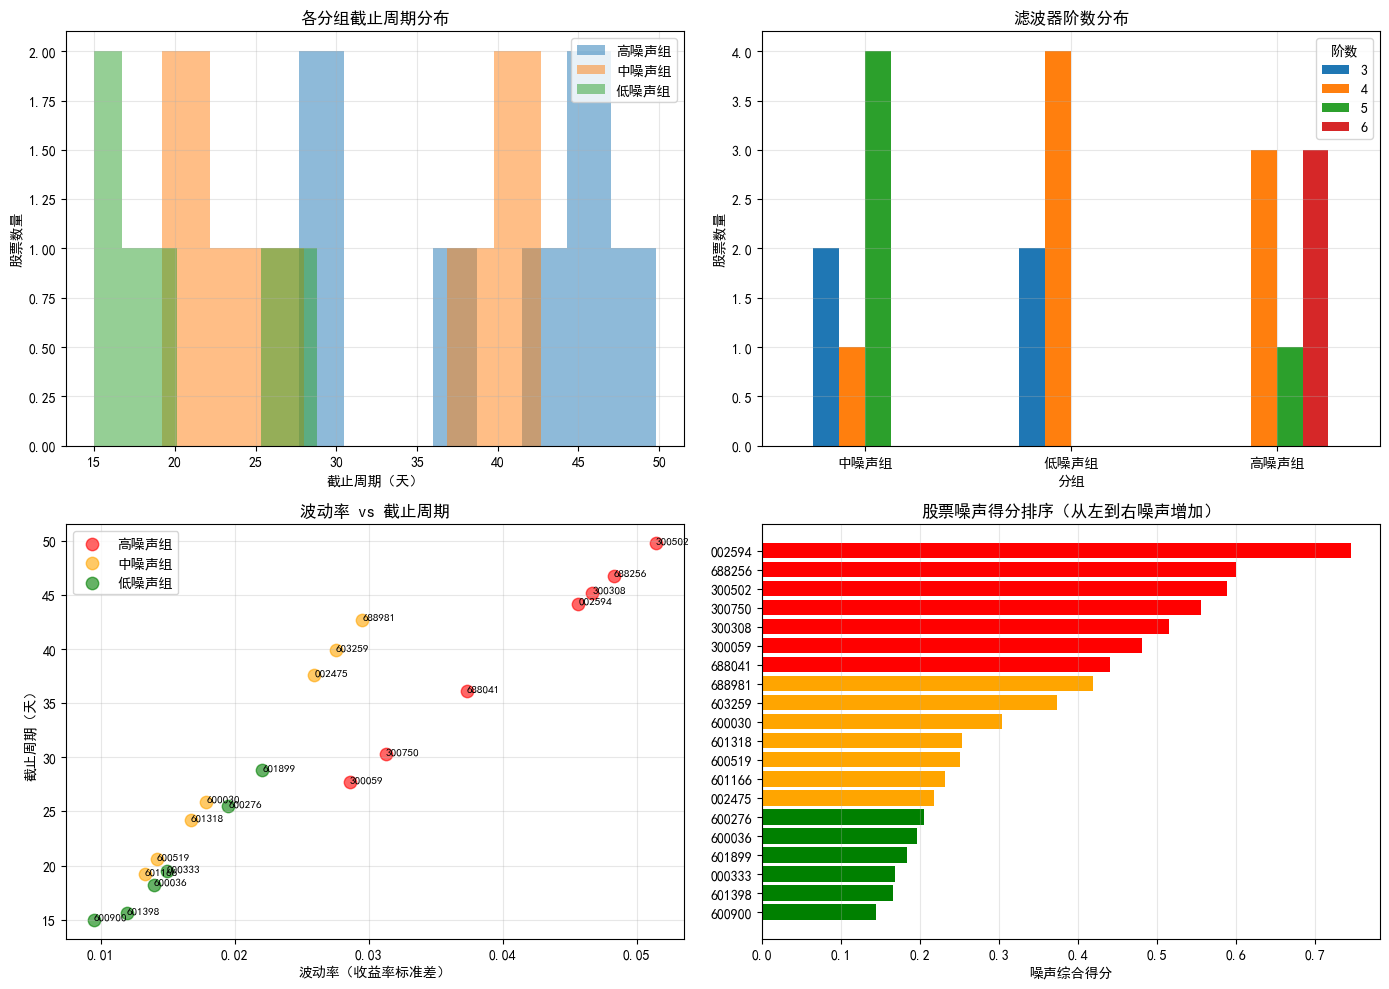

In [5]:
# 可视化不同分组的滤波器参数
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 截止周期分布
ax1 = axes[0, 0]
for group in ['高噪声组', '中噪声组', '低噪声组']:
    group_data = filter_df[filter_df['group'] == group]['cutoff_period']
    ax1.hist(group_data, alpha=0.5, label=group, bins=8)
ax1.set_xlabel('截止周期（天）')
ax1.set_ylabel('股票数量')
ax1.set_title('各分组截止周期分布')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. 滤波器阶数分布
ax2 = axes[0, 1]
order_counts = filter_df.groupby(['group', 'filter_order']).size().unstack(fill_value=0)
order_counts.plot(kind='bar', ax=ax2, rot=0)
ax2.set_xlabel('分组')
ax2.set_ylabel('股票数量')
ax2.set_title('滤波器阶数分布')
ax2.legend(title='阶数')
ax2.grid(True, alpha=0.3)

# 3. 截止周期 vs 波动率
ax3 = axes[1, 0]
colors = {'高噪声组': 'red', '中噪声组': 'orange', '低噪声组': 'green'}
for group in filter_df['group'].unique():
    group_data = filter_df[filter_df['group'] == group]
    group_noise = df_noise[df_noise['group'] == group]
    ax3.scatter(group_noise['收益率标准差（波动率）'], 
                group_data['cutoff_period'],
                c=colors[group], label=group, s=80, alpha=0.6)
    for _, row in group_data.iterrows():
        noise_row = df_noise[df_noise['code'] == row['code']].iloc[0]
        ax3.annotate(row['code'].split('.')[0], 
                    (noise_row['收益率标准差（波动率）'], row['cutoff_period']),
                    fontsize=8)
ax3.set_xlabel('波动率（收益率标准差）')
ax3.set_ylabel('截止周期（天）')
ax3.set_title('波动率 vs 截止周期')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. 噪声得分排序
ax4 = axes[1, 1]
df_sorted = df_noise.sort_values('noise_score', ascending=True)
colors_bar = [colors[g] for g in df_sorted['group']]
ax4.barh(range(len(df_sorted)), df_sorted['noise_score'], color=colors_bar)
ax4.set_yticks(range(len(df_sorted)))
ax4.set_yticklabels(df_sorted['code'].str.split('.').str[0])
ax4.set_xlabel('噪声综合得分')
ax4.set_title('股票噪声得分排序（从左到右噪声增加）')
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(r'../图表/滤波器参数设置.png', dpi=150, bbox_inches='tight')
plt.show()